In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import importlib
import astropy.units as u
import astropy.constants as c

import sys
sys.path.append('/global/homes/c/cpopik/CAPPIBARAS')

import Models.Studies as Studies
import Models.HaloModels as HaloModels
import Plots, HODs

import matplotlib.cm as cm
# Plot Styling
plt.style.use('dark_background')
plt.rcParams.update({
    'font.family':'serif', 'mathtext.fontset':'dejavuserif',
    'axes.grid':True, 'grid.linestyle': ':', 'grid.alpha': 0.5,
    'xtick.direction':'in', 'xtick.minor.visible': True, 'xtick.top':True,
    'ytick.direction':'in', 'ytick.minor.visible': True, 'ytick.right':True,
})

# Checked

## Zheng 2005

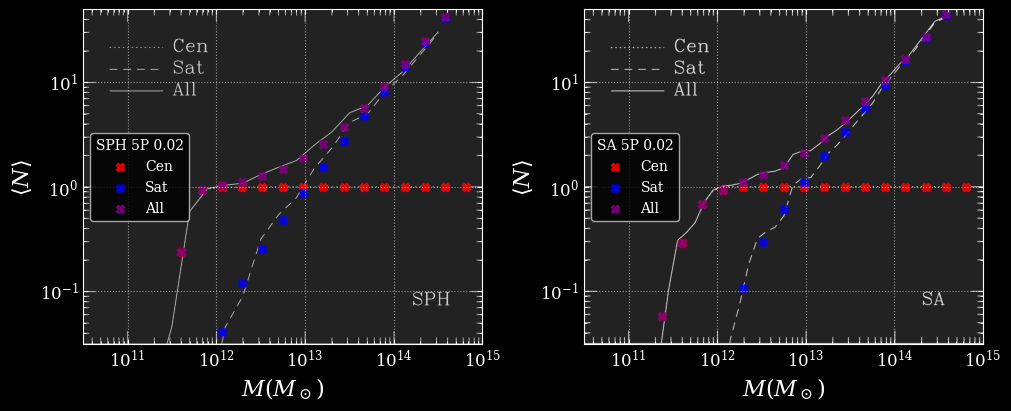

In [5]:
importlib.reload(Plots); importlib.reload(Studies); importlib.reload(HODs)
fig, axs = Plots.Zheng2005().Fig1()

logMh = np.linspace(10, 15.5, 25)

for ax, model in zip(axs, ['SPH', 'SA']):
    Z05 = HODs.Zheng2005(model=model, nparams='5P', ng='0.02')
    ax.scatter(10**logMh, Z05.Ncen(logMh)(), marker='X', c='red', alpha=0.8, label='Cen')
    ax.scatter(10**logMh, Z05.Nsat(logMh)(), marker='X', c='blue', alpha=0.8, label='Sat')
    ax.scatter(10**logMh, Z05.Ntot(logMh)(), marker='X', alpha=0.8, c='purple', label='All')
    ax.legend(loc='center left', title=f'{model} 5P 0.02')

plt.show()

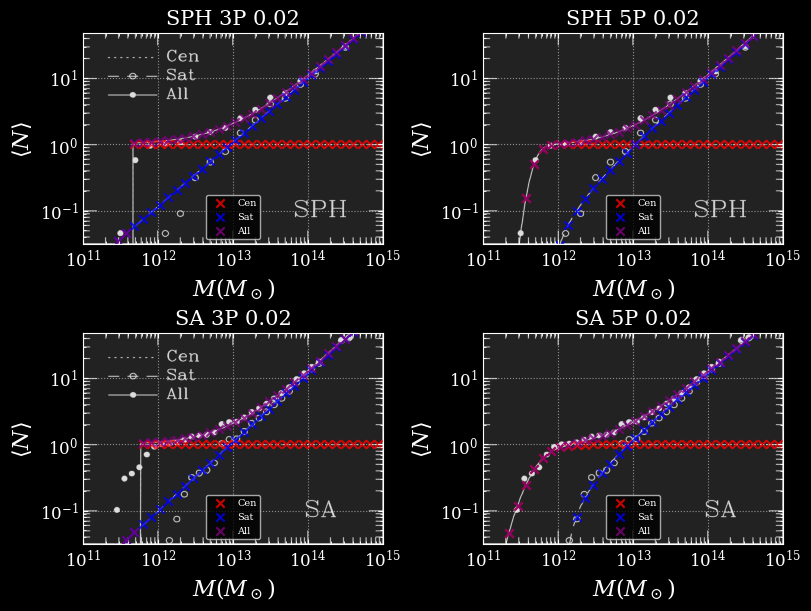

In [6]:
importlib.reload(Plots); importlib.reload(HODs); importlib.reload(HaloModels)
fig, axs = Plots.Zheng2005().Fig3()
axs = axs.flatten()
logMh = np.linspace(10, 15.5, 50)

configs = [("SPH", "3P"),("SPH", "5P"),("SA",  "3P"),("SA",  "5P")]
for ax, (model, nparams) in zip(axs, configs):
    Z05 = HODs.Zheng2005(model=model, nparams=nparams, ng="0.02")
    ax.set_title(f"{model} {nparams} 0.02", size=15)
    ax.scatter(10**logMh, Z05.Ncen(logMh)(), marker="x", c="red", alpha=0.8, label="Cen")
    ax.scatter(10**logMh, Z05.Nsat(logMh)(), marker="x", c="blue", alpha=0.8, label="Sat")
    ax.scatter(10**logMh, Z05.Ntot(logMh)(), marker="x", c="purple", alpha=0.8, label="All")
    ax.legend(loc="lower center", fontsize=7)

plt.show()

In [12]:
# importlib.reload(Plots); importlib.reload(HODs); importlib.reload(Studies); importlib.reload(HaloModels)
# fig, axs = plt.subplots(1,1)

# logMh = 12
# z=0.5
# ks=np.geomspace(1e-3, 1e4)/u.Mpc
# ks = ks
# z= np.array([z])
# logMh = np.array([logMh])

# Z05 = HODs.Zheng2005(model=model, nparams=nparams, ng="0.02")
# print(ks, z, logMh)
# plt.plot(ks, Z05.nsat(ks, z, logMh)()[:, 0, 0])
# plt.plot(ks, Z05.ncen(ks, z, logMh)({'asda':2})[:, 0, 0])

## Kusiak 2022

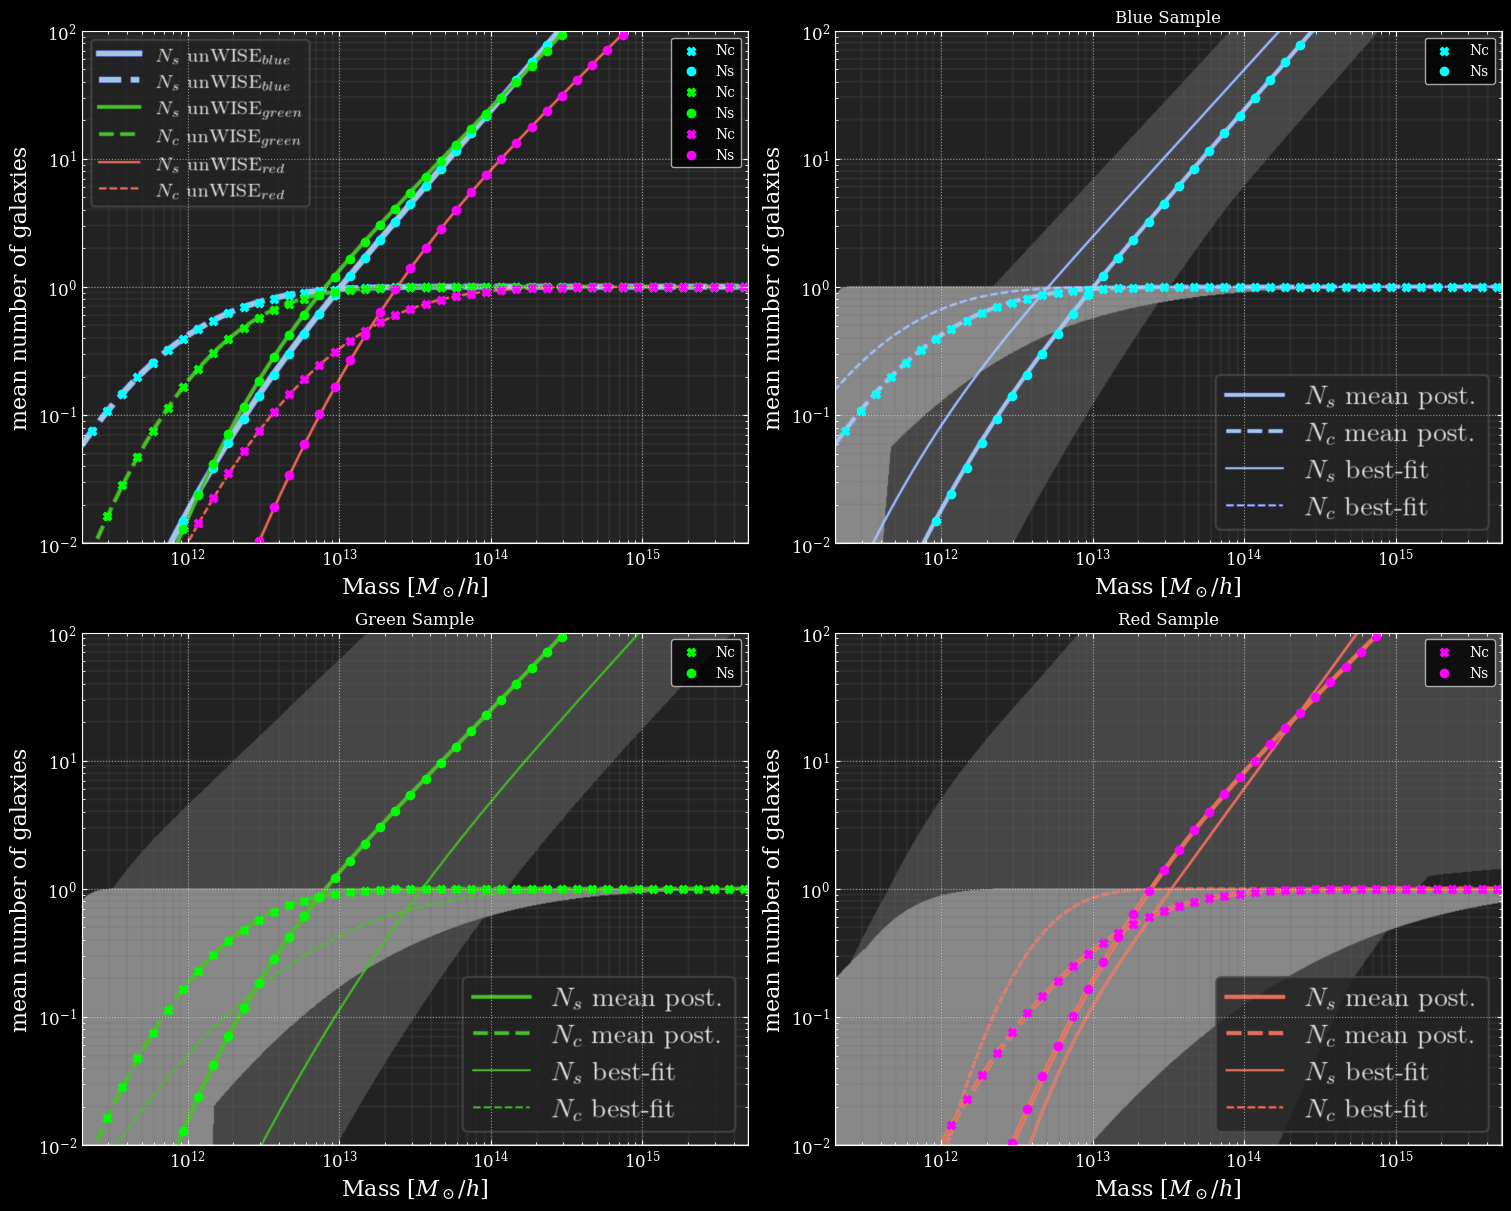

In [7]:
importlib.reload(Plots); importlib.reload(HODs)
fig, axs = Plots.Kusiak2022().Fig9()

axs = axs.flatten()
logMh = np.linspace(11, 15.9, 50)

colors = ['cyan', 'lime', 'magenta']
for i, sample in enumerate(['Blue', 'Green', 'Red']):
    K22 = HODs.Kusiak2022({'sample':sample})
    axs[0].scatter(10**logMh/K22.h, K22.Ncen(logMh)(), marker='X', c=colors[i], label='Nc')
    axs[0].scatter(10**logMh/K22.h, K22.Nsat(logMh)(), c=colors[i], label='Ns')
    axs[i+1].scatter(10**logMh/K22.h, K22.Ncen(logMh)(), marker='X', c=colors[i], label='Nc')
    axs[i+1].scatter(10**logMh/K22.h, K22.Nsat(logMh)(), c=colors[i], label='Ns')

axs[0].legend(); axs[1].legend(); axs[2].legend(); axs[3].legend()
axs[1].set(title='Blue Sample'); axs[2].set(title='Green Sample'); axs[3].set(title='Red Sample')
plt.show()

## Yuan 2023

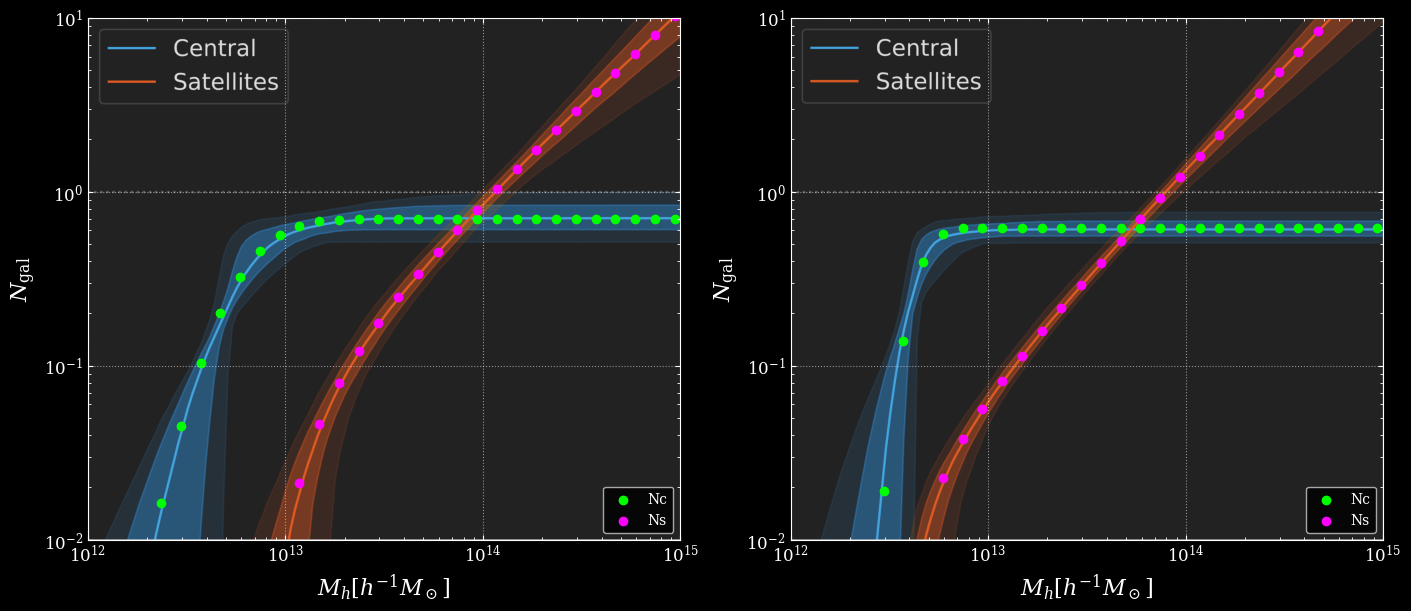

In [14]:
importlib.reload(Plots); importlib.reload(HODs)
fig, axs = Plots.Yuan2023().Fig7()
logMh = np.linspace(11, 15.9)

Y23 = HODs.Yuan2023(model='Ext',sample='LRG1')
axs[0].scatter(10**logMh/Y23.h, Y23.Ncen(logMh)(), c='lime', label='Nc')
axs[0].scatter(10**logMh/Y23.h, Y23.Nsat(logMh)(), c='magenta', label='Ns')

Y23 = HODs.Yuan2023(model='Ext',sample='LRG2')
axs[1].scatter(10**logMh/Y23.h, Y23.Ncen(logMh)(), c='lime', label='Nc')
axs[1].scatter(10**logMh/Y23.h, Y23.Nsat(logMh)(), c='magenta', label='Ns')

axs[0].legend(loc='lower right'); axs[1].legend(loc='lower right')
plt.show()

# Unchecked

## More 2015

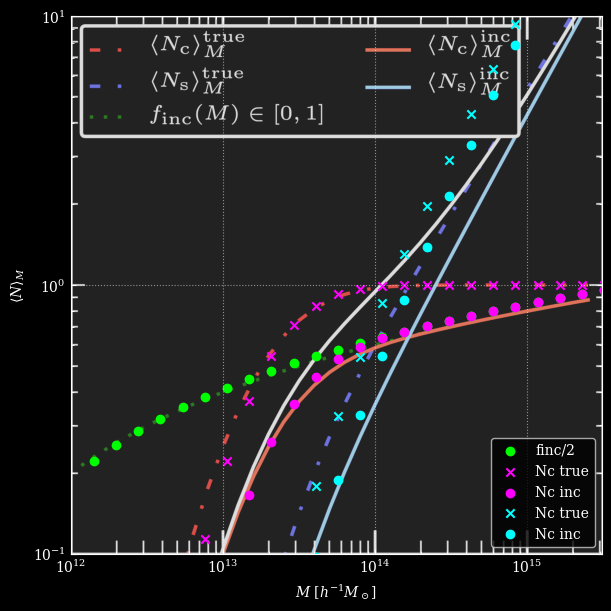

In [21]:
importlib.reload(Plots); importlib.reload(HODs)
fig, ax = Plots.More2015().Fig2()
logMh = np.linspace(12, 15.5, 25)

M15 = HODs.More2015(mbin='MA')

p=M15.p0

finc_func = lambda logM: lambda p=M15.p0: (1+p['alpha_inc']*((logM-np.log10(M15.h**2))-p['logM_inc']))/2
ax.scatter(10**logMh/M15.h, finc_func(logMh)(p), c='lime', label='finc/2')

ax.scatter(10**logMh/M15.h, M15.Ncen(logMh)(p)/finc_func(logMh)(p), c='magenta', marker='x', label='Nc true')
ax.scatter(10**logMh/M15.h, M15.Ncen(logMh)(p), c='magenta', marker='o', label='Nc inc')

ax.scatter(10**logMh/M15.h, M15.Nsat(logMh)(p)/finc_func(logMh)(p), c='cyan', marker='x', label='Nc true')
ax.scatter(10**logMh/M15.h, M15.Nsat(logMh)(p), c='cyan', marker='o', label='Nc inc')

ax.legend(loc='lower right')
plt.show()

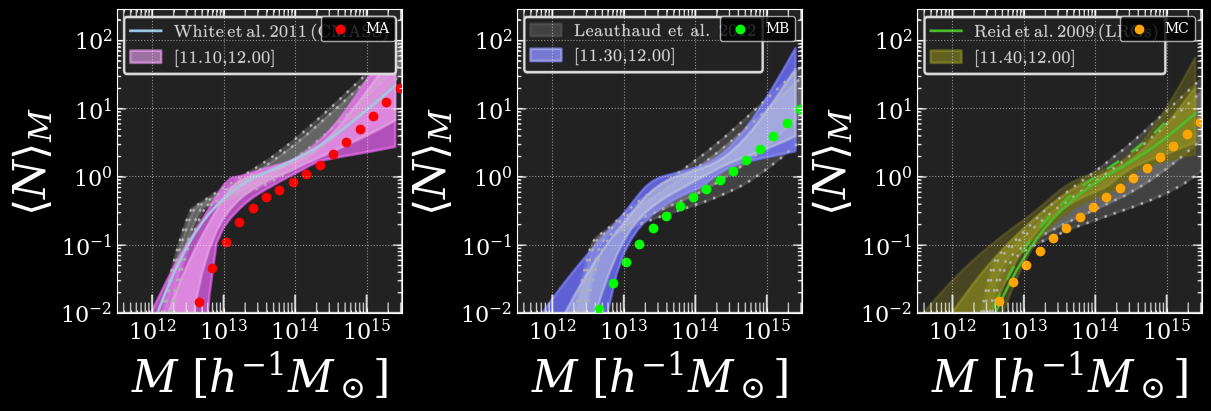

In [24]:
importlib.reload(Plots); importlib.reload(HODs)
fig, axs = Plots.More2015().Fig4()
logMh = np.linspace(11, 15.5, 25)
pars = {'alpha_inc':0}

M15 = HODs.More2015({'mbin':'MA'})
axs[0].scatter(10**logMh/M15.h, M15.Ntot(logMh)(pars),c='red', label='MA')

M15 = HODs.More2015({'mbin':'MB'})
axs[1].scatter(10**logMh/M15.h, M15.Ntot(logMh)(pars),c='lime', label='MB')

M15 = HODs.More2015({'mbin':'MC'})
axs[2].scatter(10**logMh/M15.h, M15.Ntot(logMh)(pars),c='orange', label='MC')

axs[0].legend(); axs[1].legend(); axs[2].legend()
plt.show()

## Kou 2023

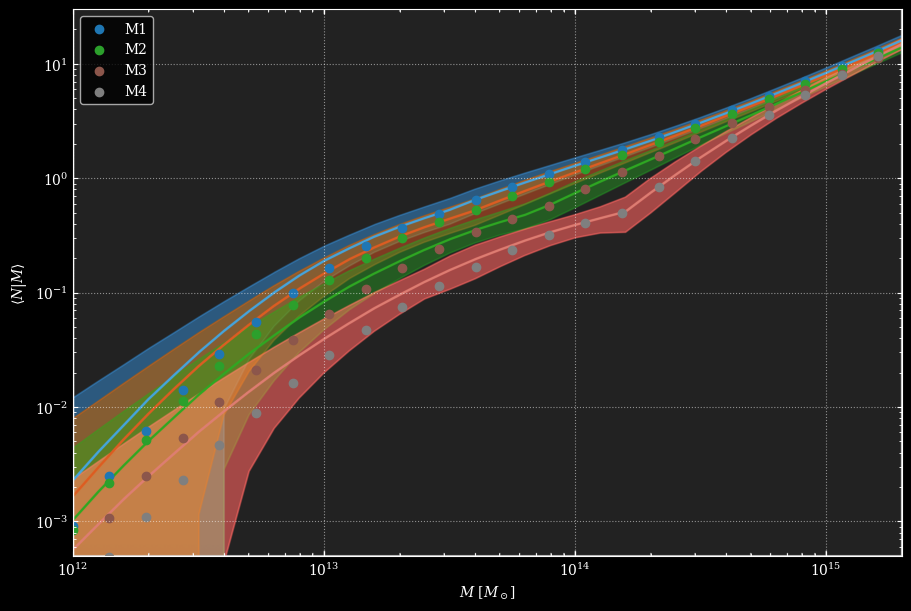

In [94]:
importlib.reload(Plots); importlib.reload(HODs)
fig, ax = Plots.Kou2023().Fig8a()

logMh = np.linspace(12, 15.5, 25)
colors = plt.cm.tab10(np.linspace(0, 1, 5))
for i, mbin in enumerate(HODs.Kou2023.models['mbin']):
    K23 = HODs.Kou2023({'mbin':mbin})
    ax.scatter(10**logMh, K23.Ntot(logMh)(), color=colors[i], label=mbin)

ax.legend()
plt.show()

## Yuan 2023

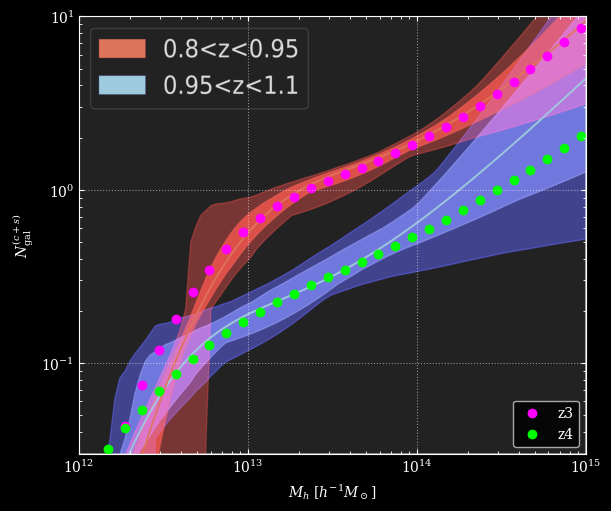

In [31]:
importlib.reload(Plots); importlib.reload(HODs)
fig, ax = Plots.Yuan2023().Fig10()

logMh = np.linspace(11, 15.9)

Y23_3 = HODs.Yuan2023(model='Base',sample='LRG3')
ax.scatter(10**logMh/Y23_3.h, Y23_3.Ntot(logMh)(), c='magenta', label='z3')

Y23_4 = HODs.Yuan2023(model='Base',sample='LRG4')
ax.scatter(10**logMh/Y23_4.h, Y23_4.Ntot(logMh)(), c='lime', label='z4')

ax.legend(loc='lower right')
plt.show()

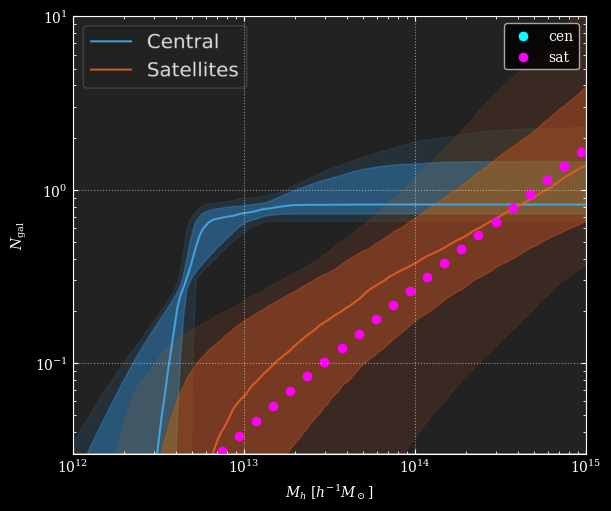

In [33]:
importlib.reload(Plots); importlib.reload(HODs)

fig, ax = Plots.Yuan2023().Fig14()

logMh = np.linspace(11, 15.9)

Yuan2023 = HODs.Yuan2023(model='Ext',sample='QSO')
ax.scatter(10**logMh/Yuan2023.h, Yuan2023.Ncen(logMh)(), c='cyan', label='cen')
ax.scatter(10**logMh/Yuan2023.h, Yuan2023.Nsat(logMh)(), c='magenta', label='sat')

ax.legend()
plt.show()

## Kusiak 2022

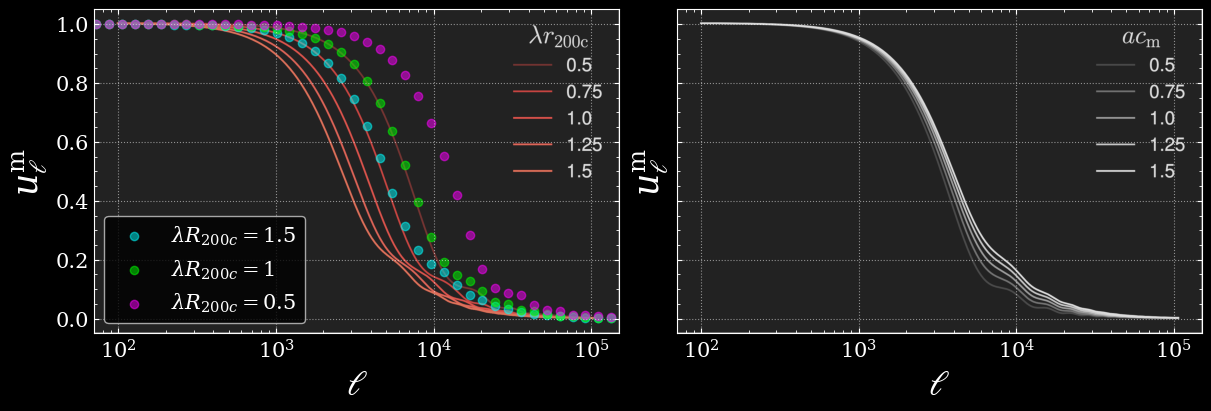

In [ ]:
fig, axs = Plots.Kusiak2022().Fig15()

import HODs, HaloModels
import Studies
import Models.Studies as Studies

importlib.reload(Studies)
importlib.reload(HODs); importlib.reload(HaloModels)

hmod = HaloModels.colossus_model(**HODs.Kusiak2022().info)

ks = np.geomspace(1e-2, 1e2)

z, logMh = 0.5, np.log10(3e14/HODs.Kusiak2022().h)
c200c0, ells0 = 3.4, ks*(1317/HODs.Kusiak2022().h)-0.5
ells = ks/u.Mpc*hmod.chi(z)-0.5
r200c = hmod.rdel('200c')(z, logMh).value
prefac = 10**logMh*u.Msun/hmod.rhom(0)

Kusiak2022 = HODs.Kusiak2022({'sample':'Blue'}, rhom=hmod.rhom, r200c=hmod.rdel('200c'), c200c=hmod.c)
axs[0].scatter(ells, Kusiak2022.nsat(ks, z, logMh)({'Lambda':1.5/r200c})[:, 0, 0]/prefac, color='cyan', alpha=0.5, label=r'$\lambda R_{200c}=1.5$')
axs[0].scatter(ells, Kusiak2022.nsat(ks, z, logMh)({'Lambda':1/r200c})[:, 0, 0]/prefac, color='lime', alpha=0.5, label=r'$\lambda R_{200c}=1$')
axs[0].scatter(ells, Kusiak2022.nsat(ks, z, logMh)({'Lambda':0.5/r200c})[:, 0, 0]/prefac, color='magenta', alpha=0.5, label=r'$\lambda R_{200c}=0.5$')

axs[0].legend(loc='lower left')
plt.show()

## Linke 2022

$\langle N_\text{cen}^a | m \rangle = \frac{\alpha_a}{2} \Bigg\{ 1+\text{erf} \bigg[ \frac{\log (m) - \log (M_\text{th}^a)}{\sigma^a}\bigg] \Bigg\}  \qquad \text{(36)}$

$\langle N_\text{sat}^a | m \rangle = \frac{1}{2} \Bigg\{ 1+\text{erf} \bigg[ \frac{\log (m) - \log (M_\text{th}^a)}{\sigma^a}\bigg] \Bigg\} \Big( \frac{m}{M'^{a}}\Big)^{\beta^a} \qquad \text{(37)}$

$\rho(r | m, z) = \frac{200\bar{\rho}(z)}{2\frac{r}{r_{200}} \big[ \frac{1}{c(m,z)}+\frac{r}{r_{200}}\big]^2} \ \frac{1+c(m,z)}{\ln (1+c(m, z)) [1+c(m,z)]-c} = m u(r|m, z) \qquad \text{(23)}$

$\langle N_\text{sat}^a | m \rangle u_\text{g}^a (\textbf{x}|m) = u(r|m, z, c_\text{g}^a=f^a c) \qquad \text{(34)}$

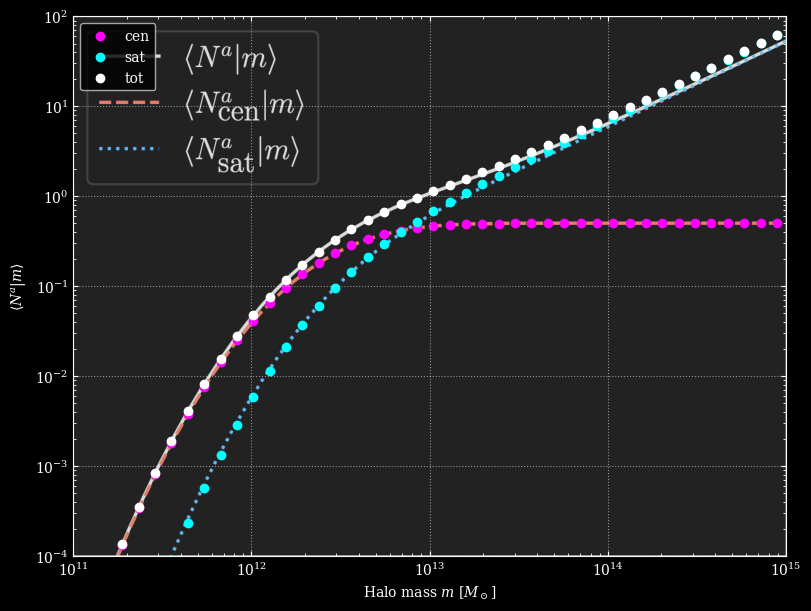

In [148]:
importlib.reload(Plots); importlib.reload(HODs); importlib.reload(Studies)

fig, ax = Plots.Linke2022().Fig2()

logMh = np.linspace(11, 15.5)
L22 = HODs.Linke2022({'sample':'KVG', 'color':'b'})
pfid = {'alpha_a':0.5, 'sigma_a':0.5, 'M_th_a':10**12.5/1e11, 'beta_a':1, 'M_a':10**13.5/1e13}
ax.scatter(10**logMh, L22.Ncen(logMh)(pfid),c='magenta', label='cen')
ax.scatter(10**logMh, L22.Nsat(logMh)(pfid), c='cyan', label='sat' )
ax.scatter(10**logMh, L22.Ntot(logMh)(pfid), c='w', label='tot')

ax.legend()
plt.show()

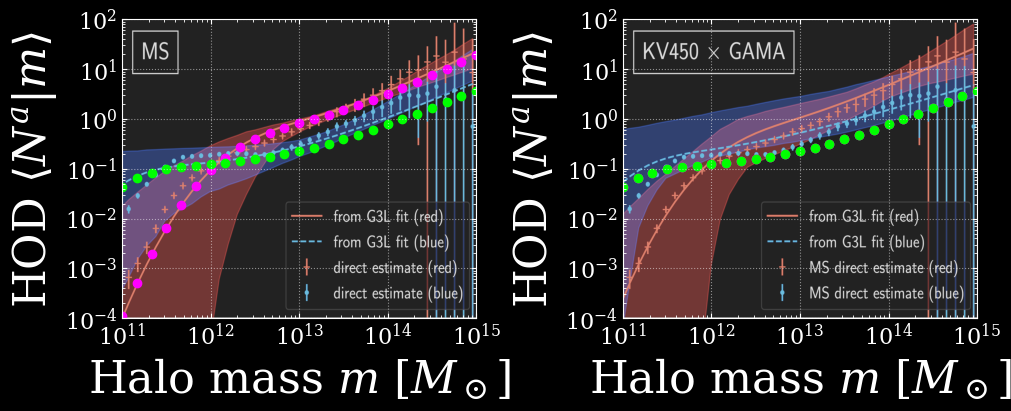

In [ ]:
importlib.reload(Plots); importlib.reload(HODs); importlib.reload(Studies)
fig, axs = Plots.Linke2022().Fig8()

logMh = np.linspace(11, 15, 25)

L22 = HODs.Linke2022({'sample':'MS', 'color':'r'})
axs[0].scatter(10**logMh, L22.Ntot(logMh)(),c='magenta', label='red')
L22 = HODs.Linke2022({'sample':'MS', 'color':'b'})
axs[0].scatter(10**logMh, L22.Ntot(logMh)(),c='lime', label='blue')

Linke2022 = HODs.Linke2022({'sample':'KVG', 'color':'r'})
axs[1].scatter(10**logMh, L22.Ntot(logMh)(),c='magenta', label='red')
Linke2022 = HODs.Linke2022({'sample':'KVG', 'color':'b'})
axs[1].scatter(10**logMh, L22.Ntot(logMh)(),c='lime', label='blue')

ax.legend()
plt.show()

## Hadzhiyska 2025B

In [48]:
zbins   = ["z1", "z2", "z3", "z4", "all"]
samples = ["LRG_main", "LRG_extended", "BGS"]
params  = ["logMcut", "logM1", "sigma_logM", "alpha", "kappa", "nbar_x1000", "fsat", "logMh_bar"]

values = [
#logMcut
[[12.61, 12.63, 12.73, 12.63, 12.683], [12.49, 12.44, 12.52, 12.38, 12.491], [None, None, None, None, 12.133]],
#logM1
[[13.91, 14.02, 13.98, 13.97, 14.063], [13.96, 14.01, 14.05, 14.10, 14.196], [None, None, None, None, 13.83 ]],
#sigma_logM
[[ 0.30,  0.18,  0.21,  0.23,  0.133], [ 0.24,  0.14,  0.17,  0.20,  0.108], [None, None, None, None,  0.107]],
#alpha
[[ 1.00,  0.84,  0.96,  0.96,  0.848], [ 0.92,  0.76,  0.89,  0.82,  0.642], [None, None, None, None,  1.219]],
#kappa
[[ 1.30,  1.30,  1.33,  1.28,  1.245], [ 1.28,  1.23,  1.23,  1.10,  0.941], [None, None, None, None,  1.069]],
#nbar_x1000
[[ 1.30,  1.09,  0.69,  0.91,  0.745], [ 1.58,  1.66,  1.16,  1.72,  1.254], [None, None, None, None,  3.608]],
#fsat
[[ 0.08,  0.09,  0.08,  0.07,  0.080], [ 0.07,  0.08,  0.06,  0.06,  0.098], [None, None, None, None,  0.108]],
#logMh_bar
[[13.19, 13.22, 13.20, 13.12, 13.179], [13.11, 13.09, 13.05, 12.92, 13.025], [None, None, None, None, 13.022]],
]

err_lo = [
[[0.15, 0.09, 0.10, 0.11, 0.063], [0.10, 0.07, 0.08, 0.07, 0.045], [None, None, None, None, 0.125]],
[[0.35, 0.41, 0.37, 0.37, 0.395], [0.37, 0.49, 0.39, 0.39, 0.433], [None, None, None, None, 0.670]],
[[0.21, 0.13, 0.14, 0.15, 0.083], [0.17, 0.10, 0.11, 0.13, 0.060], [None, None, None, None, 0.074]],
[[0.48, 0.39, 0.44, 0.45, 0.362], [0.44, 0.34, 0.40, 0.35, 0.222], [None, None, None, None, 0.770]],
[[0.88, 0.90, 0.89, 0.85, 0.816], [0.89, 0.85, 0.83, 0.79, 0.737], [None, None, None, None, 0.790]],
[[0.41, 0.25, 0.19, 0.27, 0.133], [0.43, 0.34, 0.28, 0.47, 0.198], [None, None, None, None, 0.723]],
[[0.05, 0.06, 0.05, 0.05, 0.057], [0.05, 0.06, 0.04, 0.04, 0.078], [None, None, None, None, 0.032]],
[[0.06, 0.04, 0.03, 0.04, 0.021], [0.04, 0.03, 0.03, 0.03, 0.016], [None, None, None, None, 0.061]],
]

err_hi = [
[[0.39, 0.23, 0.27, 0.32, 0.129], [0.37, 0.17, 0.25, 0.33, 0.070], [None, None, None, None, 0.102]],
[[0.33, 0.26, 0.29, 0.29, 0.241], [0.29, 0.27, 0.24, 0.21, 0.144], [None, None, None, None, 0.276]],
[[0.29, 0.25, 0.23, 0.25, 0.179], [0.31, 0.23, 0.25, 0.27, 0.126], [None, None, None, None, 0.194]],
[[0.56, 0.60, 0.57, 0.56, 0.611], [0.58, 0.66, 0.61, 0.63, 0.725], [None, None, None, None, 0.501]],
[[0.92, 0.91, 0.89, 0.91, 0.924], [0.94, 0.94, 0.94, 1.04, 1.075], [None, None, None, None, 0.992]],
[[0.60, 0.37, 0.26, 0.34, 0.223], [0.54, 0.54, 0.33, 0.35, 0.223], [None, None, None, None, 1.615]],
[[0.09, 0.10, 0.09, 0.09, 0.104], [0.10, 0.14, 0.09, 0.09, 0.091], [None, None, None, None, 0.195]],
[[0.09, 0.05, 0.05, 0.06, 0.029], [0.07, 0.04, 0.05, 0.06, 0.022], [None, None, None, None, 0.091]],
]

rows = [
    [sample, z, param, v, lo, hi]
    for param, pval, plo, phi in zip(params, values, err_lo, err_hi)
    for sample, sval, slo, shi in zip(samples, pval, plo, phi)
    for z, v, lo, hi in zip(zbins, sval, slo, shi)
    if v is not None
]

df = pd.DataFrame(rows, columns=["sample", "zbin", "param", "value", "err_lo", "err_hi"]
    ).set_index(["sample", "zbin", "param"]).sort_index()

In [52]:
df.xs("logMcut", level="param")["value"]   # all z-bins for logMcut
# df.xs("z1",      level="zbin")    # all params for z1

sample        zbin
BGS           all     12.133
LRG_extended  all     12.491
              z1      12.490
              z2      12.440
              z3      12.520
              z4      12.380
LRG_main      all     12.683
              z1      12.610
              z2      12.630
              z3      12.730
              z4      12.630
Name: value, dtype: float64

In [ ]:
, "value"

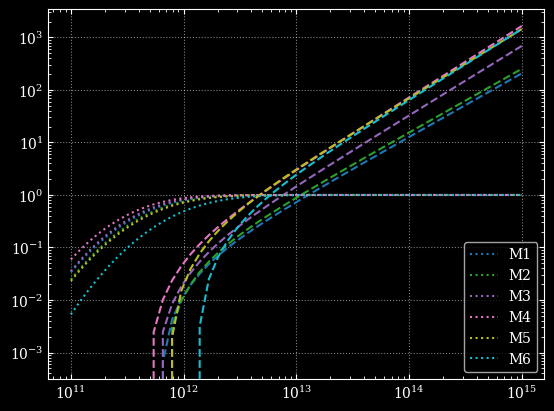

In [8]:
importlib.reload(Plots); importlib.reload(HODs); importlib.reload(Studies)
fig, ax = plt.subplots(1, 1)
logMh = np.linspace(11, 15)

colors = plt.cm.tab10(np.linspace(0, 1, 6))
for i, mbin in enumerate(['M1', 'M2', 'M3', 'M4', 'M5', 'M6']):
    B25 = HODs.Hadzhiyska2025B(mbin=mbin)
    ax.plot(10**logMh, B25.Ncen(logMh)(), ls=':', label=f'{mbin}', c = colors[i])
    ax.plot(10**logMh, B25.Nsat(logMh)(), ls='--', c = colors[i])

ax.set(xscale='log', yscale='log')
ax.legend(loc='lower right')
plt.show()

## Hadzhiyska2025A

$\langle N_\text{cen} (M) \rangle = \frac{1}{2} \bigg[1+\text{erf}\bigg(\frac{\log M - \log M_\text{cut}}{2\sigma_{\log M}}\bigg)\bigg] \qquad \text{(2)}$

$\langle N_\text{sat} (M) \rangle = \langle N_\text{cen} (M)\rangle \bigg[ \frac{M-\kappa M_\text{cut}}{M_1}\bigg]^\alpha, \text{for} M>\kappa M_\text{cut} \qquad \text{(3)}$

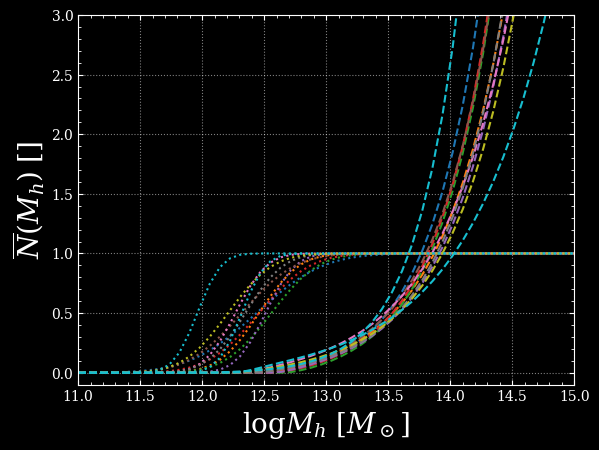

In [6]:
importlib.reload(Plots); importlib.reload(HODs)
fig, ax = plt.subplots(1, 1)
logMh = np.linspace(11, 15)

colors = plt.cm.tab10(np.linspace(0, 1, 11))

for i, samp in enumerate(HODs.Hadzhiyska2025A.models['sample']):
    B25 = HODs.Hadzhiyska2025A(sample=samp)
    ax.plot(logMh, B25.Ncen(logMh)(), ls=':', label=f'{samp}', c = colors[i])
    ax.plot(logMh, B25.Nsat(logMh)(), ls='--', c = colors[i])

ax.set_ylabel(ylabel=r'$\overline{N} (M_h) \ []$', fontsize=20); ax.set(ylim=(-0.1, 3))
ax.set_xlabel(r'log$M_h \ [M_\odot]$', fontsize=20); ax.set(xlim=(11, 15))

plt.show()

# All

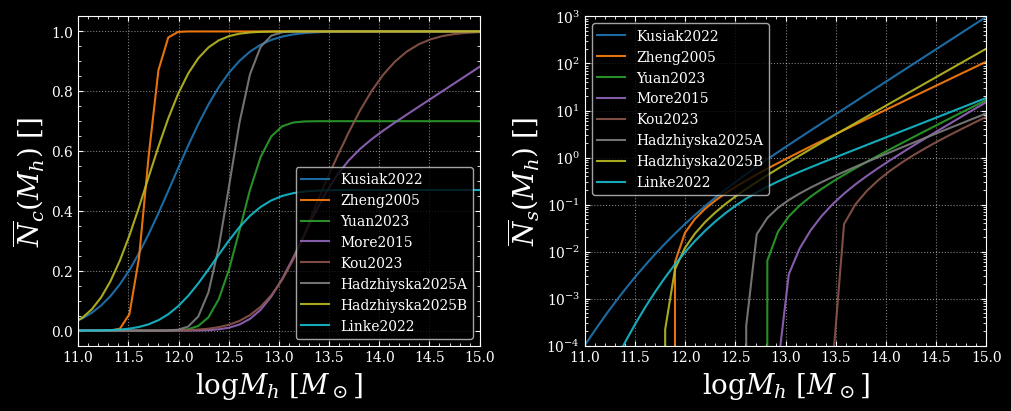

In [153]:
importlib.reload(Studies); importlib.reload(HaloModels); importlib.reload(HODs)

fig, axs = plt.subplots(1, 2, figsize=(10, 4), layout='constrained', sharex=True)
axs = axs.flatten()

logMh = np.geomspace(10, 15)

mods = [HODs.Kusiak2022({'sample':'Blue'}),
        HODs.Zheng2005(model='SPH', nparams='5P', ng='0.02'),
        HODs.Yuan2023(model='Ext',sample='LRG1'),
        
        HODs.More2015(mbin='MA'),
        HODs.Kou2023(mbin='M1'),
        HODs.Hadzhiyska2025A(sample='Main'),
        HODs.Hadzhiyska2025B(mbin='M1'),
        HODs.Linke2022({'sample':'MS', 'color':'r'})]

colors = plt.cm.tab10(np.linspace(0, 1, len(mods)))
for i, mod in enumerate(mods):
    axs[0].plot(logMh, mod.Ncen(logMh)(), label=mod.__class__.__name__, c=colors[i], alpha=0.9)
    axs[1].plot(logMh, mod.Nsat(logMh)(),  label=mod.__class__.__name__,c=colors[i], alpha=0.9)


axs[0].set_ylabel(ylabel=r'$\overline{N}_c (M_h) \ []$', fontsize=20); 
axs[1].set_ylabel(ylabel=r'$\overline{N}_s (M_h) \ []$', fontsize=20); axs[1].set(yscale='log', ylim=(1e-4, 1e3))
for ax in axs: 
    ax.set_xlabel(r'log$M_h \ [M_\odot]$', fontsize=20)
    ax.set(xlim=(11, 15))
    ax.legend()

plt.show()